In [ ]:
# __ROOTBOOT__ ensure project root on sys.path (auto-added; safe to keep)
import os as _os, sys as _sys
_r = _os.path.abspath('')
while _r != _os.path.dirname(_r) and not _os.path.exists(_os.path.join(_r, '.project_root')):
    _r = _os.path.dirname(_r)
if _os.path.exists(_os.path.join(_r, '.project_root')) and _r not in _sys.path:
    _sys.path.insert(0, _r)


# Project 2: Vol Forecasting & Risk Filter

Two questions:
1. **Can we forecast S&P 500 realized vol?** Walk-forward comparison of MPTE, AR, HAR-RV, XGB
2. **Does vol forecasting help portfolio management?** Apply risk filter using each model's forecast vs perfect foresight vs buy & hold

### Key findings
- Vol timing has theoretical value: perfect foresight Sharpe 1.49 vs buy & hold 0.92
- But no real forecast beats buy & hold (AR best at 0.89 Sharpe)
- MPTE (0.79 Sharpe) underperforms AR — transformer doesn't help for vol
- The gap between perfect and real is the research opportunity

### Prerequisites
Run `P1_data_infrastructure.ipynb` first.
```
pip install torch numpy pandas scikit-learn xgboost statsmodels matplotlib
```

---
# Part A: Walk-Forward Vol Forecasting

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import json, os, time, warnings
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.linear_model import LinearRegression, Ridge
from statsmodels.tsa.ar_model import AutoReg
from xgboost import XGBRegressor

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

DATA_DIR = './data'
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

Device: cpu


## 1. Load data

In [2]:
monthly = pd.read_csv(f'{DATA_DIR}/monthly_panel_transformed.csv', index_col=0, parse_dates=True)
quarterly = pd.read_csv(f'{DATA_DIR}/quarterly_panel_transformed.csv', index_col=0, parse_dates=True)
rv_target = pd.read_csv(f'{DATA_DIR}/rv_target_quarterly.csv', index_col=0, parse_dates=True).squeeze()

assert monthly.shape[1] > 0, 'Monthly panel empty — re-run notebook 1.'
print(f'Monthly: {monthly.shape}, Quarterly: {quarterly.shape}, RV: {len(rv_target)} quarters')
print(f'RV range: {rv_target.index.min()} to {rv_target.index.max()}')

Monthly: (502, 27), Quarterly: (168, 5), RV: 168 quarters
RV range: 1984-03-31 00:00:00 to 2025-12-31 00:00:00


In [4]:
# Load S&P 500 quarterly returns for allocation backtest
import sys
sys.path.append(r'C:\Users\danie\Downloads\algo_trading')
from _shared.loaders_wrds import load_sp500_daily

sp500_raw = load_sp500_daily()
if 'datadate' in sp500_raw.columns:
    sp500_raw = sp500_raw.set_index('datadate')
sp500_raw.index = pd.DatetimeIndex(sp500_raw.index)
sp500_raw = sp500_raw.sort_index()

prices = sp500_raw['prccd'].astype(float)
quarterly_prices = prices.resample('Q').last()
quarterly_returns = quarterly_prices.pct_change().dropna()
quarterly_returns.name = 'sp500_ret'

print(f'Quarterly returns: {len(quarterly_returns)} quarters')

Loaded 08_na_index_daily_prices.parquet: 8,586,924 rows x 10 cols
Quarterly returns: 170 quarters


## 2. Model & dataset definitions

Same as notebook 2, copied here for self-containment.

In [5]:
# --- Long-format data ---
def build_long_format(monthly_df, quarterly_df):
    records = []
    for col in monthly_df.columns:
        s = monthly_df[col].dropna()
        for date, val in s.items():
            records.append({'date': date, 'variable': col, 'value': val, 'freq': 'M'})
    for col in quarterly_df.columns:
        s = quarterly_df[col].dropna()
        for date, val in s.items():
            records.append({'date': date, 'variable': col, 'value': val, 'freq': 'Q'})
    df = pd.DataFrame(records)
    df['date'] = pd.to_datetime(df['date'])
    return df.sort_values('date').reset_index(drop=True)

long_data = build_long_format(monthly, quarterly)
all_vars = sorted(long_data['variable'].unique())
var_to_id = {v: i for i, v in enumerate(all_vars)}
freq_to_id = {'M': 0, 'Q': 1}
long_data['var_id'] = long_data['variable'].map(var_to_id)
long_data['freq_id'] = long_data['freq'].map(freq_to_id)
print(f'Long-format: {len(long_data)} obs, {len(all_vars)} variables')

Long-format: 14394 obs, 32 variables


In [6]:
# --- Dataset ---
class MPTEDataset(Dataset):
    def __init__(self, long_data, rv_target, quarter_indices,
                 context_months=24, scaler=None, fit_scaler=False, use_log_rv=True):
        self.long_data = long_data
        self.rv_target = rv_target
        self.quarter_indices = quarter_indices
        self.context_months = context_months
        self.use_log_rv = use_log_rv
        if fit_scaler:
            self.scaler = StandardScaler()
            train_dates = rv_target.index[quarter_indices]
            mask = long_data['date'] <= train_dates.max()
            self.scaler.fit(long_data.loc[mask, ['value']])
        else:
            self.scaler = scaler
        self.sequences, self.targets = [], []
        self._build()
    
    def _build(self):
        for idx in self.quarter_indices:
            td = self.rv_target.index[idx]
            ws = td - pd.DateOffset(months=self.context_months)
            we = td - pd.DateOffset(days=1)
            mask = (self.long_data['date'] >= ws) & (self.long_data['date'] <= we)
            w = self.long_data[mask]
            if len(w) == 0: continue
            vals = self.scaler.transform(w[['value']]).flatten()
            ti = (td - w['date']).dt.days.values / 30.0
            self.sequences.append({
                'values': torch.tensor(vals, dtype=torch.float32),
                'var_ids': torch.tensor(w['var_id'].values, dtype=torch.long),
                'freq_ids': torch.tensor(w['freq_id'].values, dtype=torch.long),
                'time_idx': torch.tensor(ti, dtype=torch.float32),
            })
            rv = self.rv_target.iloc[idx]
            self.targets.append(np.log(rv) if self.use_log_rv else rv)
    
    def __len__(self): return len(self.sequences)
    def __getitem__(self, idx):
        return self.sequences[idx], torch.tensor(self.targets[idx], dtype=torch.float32)

def collate_fn(batch):
    seqs, targets = zip(*batch)
    ml = max(s['values'].shape[0] for s in seqs)
    B = len(seqs)
    bv = torch.zeros(B, ml); bvi = torch.zeros(B, ml, dtype=torch.long)
    bfi = torch.zeros(B, ml, dtype=torch.long); bti = torch.zeros(B, ml)
    bm = torch.ones(B, ml, dtype=torch.bool)
    for i, s in enumerate(seqs):
        L = s['values'].shape[0]
        bv[i,:L]=s['values']; bvi[i,:L]=s['var_ids']
        bfi[i,:L]=s['freq_ids']; bti[i,:L]=s['time_idx']; bm[i,:L]=False
    return {'values':bv,'var_ids':bvi,'freq_ids':bfi,'time_idx':bti,'mask':bm}, torch.stack(targets)

print('Dataset defined.')

Dataset defined.


In [7]:
# --- MPTE Model ---
class MPTE(nn.Module):
    def __init__(self, n_vars, n_freqs=2, d_var=8, d_freq=2,
                 d_model=32, nhead=2, n_layers=1, d_ff=64,
                 dropout=0.15, activation='gelu'):
        super().__init__()
        self.d_model = d_model
        self.var_embedding = nn.Embedding(n_vars, d_var)
        self.freq_embedding = nn.Embedding(n_freqs, d_freq)
        self.input_proj = nn.Linear(1 + d_var + d_freq, d_model)
        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_ff,
            dropout=dropout, activation=activation, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model//2), nn.GELU(),
            nn.Dropout(dropout), nn.Linear(d_model//2, 1))
    
    def temporal_encoding(self, ti):
        d = self.d_model
        pe = torch.zeros(*ti.shape, d, device=ti.device)
        pos = ti.unsqueeze(-1)
        div = torch.exp(torch.arange(0,d,2,device=ti.device).float()*(-np.log(10000.0)/d))
        pe[...,0::2] = torch.sin(pos*div); pe[...,1::2] = torch.cos(pos*div)
        return pe
    
    def forward(self, values, var_ids, freq_ids, time_idx, mask=None):
        x = torch.cat([values.unsqueeze(-1), self.var_embedding(var_ids),
                       self.freq_embedding(freq_ids)], dim=-1)
        x = self.input_proj(x) + self.temporal_encoding(time_idx)
        x = self.encoder(x, src_key_padding_mask=mask)
        if mask is not None:
            m = (~mask).unsqueeze(-1).float()
            x = (x*m).sum(1) / m.sum(1).clamp(min=1)
        else: x = x.mean(1)
        return self.head(x).squeeze(-1)

print(f'MPTE defined. Vars: {len(all_vars)}')

MPTE defined. Vars: 32


In [8]:
# --- Training utilities ---
def train_mpte_quiet(model, train_ds, val_ds, epochs=150, lr=3e-4, batch_size=16, patience=15):
    """Train MPTE silently (for walk-forward loop)."""
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_ds, batch_size=max(1,len(val_ds)), shuffle=False, collate_fn=collate_fn)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=5, factor=0.5)
    criterion = nn.MSELoss()
    best_val, best_state, no_imp = float('inf'), None, 0
    
    for epoch in range(epochs):
        model.train()
        for bx, by in train_loader:
            pred = model(bx['values'].to(device), bx['var_ids'].to(device),
                         bx['freq_ids'].to(device), bx['time_idx'].to(device), bx['mask'].to(device))
            loss = criterion(pred, by.to(device))
            optimizer.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        
        model.eval()
        with torch.no_grad():
            for bx, by in val_loader:
                pred = model(bx['values'].to(device), bx['var_ids'].to(device),
                             bx['freq_ids'].to(device), bx['time_idx'].to(device), bx['mask'].to(device))
                vl = criterion(pred, by.to(device)).item()
        
        scheduler.step(vl)
        if vl < best_val:
            best_val = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_imp = 0
        else:
            no_imp += 1
        if no_imp >= patience: break
    
    model.load_state_dict(best_state)
    return model


def predict_single(model, dataset, use_log_rv=True):
    """Predict on a dataset, return arrays."""
    loader = DataLoader(dataset, batch_size=max(1,len(dataset)), shuffle=False, collate_fn=collate_fn)
    model.eval()
    with torch.no_grad():
        for bx, by in loader:
            pred = model(bx['values'].to(device), bx['var_ids'].to(device),
                         bx['freq_ids'].to(device), bx['time_idx'].to(device),
                         bx['mask'].to(device)).cpu().numpy()
            true = by.numpy()
            if use_log_rv:
                pred, true = np.exp(pred), np.exp(true)
            return pred, true

print('Training utilities defined.')

Training utilities defined.


## 3. Walk-Forward Configuration

- **Initial training window**: first 60% of data (~25 years)
- **Validation**: next 10% (~4 years)
- **Retrain frequency**: every 4 quarters (annually)
- **Expanding window**: training set grows each year, val slides forward
- Predict each quarter individually, always out-of-sample

In [9]:
N = len(rv_target)
INIT_TRAIN_PCT = 0.60
VAL_QUARTERS = 12  # 3 years for validation
RETRAIN_EVERY = 4  # retrain annually

init_train_end = int(N * INIT_TRAIN_PCT)
first_test_idx = init_train_end + VAL_QUARTERS

print(f'Total quarters: {N}')
print(f'Initial train: 0 to {init_train_end-1} ({init_train_end} quarters, ending {rv_target.index[init_train_end-1]})')
print(f'Initial val: {init_train_end} to {first_test_idx-1} ({VAL_QUARTERS} quarters)')
print(f'Walk-forward test: {first_test_idx} to {N-1} ({N - first_test_idx} quarters)')
print(f'Test period: {rv_target.index[first_test_idx]} to {rv_target.index[-1]}')
print(f'Retrain every {RETRAIN_EVERY} quarters')
print(f'Estimated retraining rounds: {(N - first_test_idx) // RETRAIN_EVERY + 1}')

Total quarters: 168
Initial train: 0 to 99 (100 quarters, ending 2008-12-31 00:00:00)
Initial val: 100 to 111 (12 quarters)
Walk-forward test: 112 to 167 (56 quarters)
Test period: 2012-03-31 00:00:00 to 2025-12-31 00:00:00
Retrain every 4 quarters
Estimated retraining rounds: 15


## 4. Walk-Forward Loop

In [12]:
# Prepare quarterly features for benchmarks (same as notebook 2)
monthly_qtr = monthly.resample('Q').last()
quarterly_qtr = quarterly.resample('Q').last()
X_bench = pd.concat([monthly_qtr, quarterly_qtr], axis=1).ffill().bfill().fillna(0)
X_bench = X_bench.dropna(axis=1, how='all')

common_idx = X_bench.index.intersection(rv_target.index)
X_bench = X_bench.loc[common_idx]
y_bench = rv_target.loc[common_idx]

# Shift for next-quarter prediction
X_bench = X_bench.shift(1).iloc[1:]
y_bench = y_bench.iloc[1:]

print(f'Benchmark features: {X_bench.shape}')

Benchmark features: (166, 32)


In [13]:
# Walk-forward loop
wf_results = {name: {'dates': [], 'pred': [], 'true': []} 
              for name in ['MPTE', 'AR', 'HAR-RV', 'Ridge', 'XGB']}

last_retrain = -999  # force initial training
mpte_model = None

start_time = time.time()

for test_q in range(first_test_idx, N):
    test_date = rv_target.index[test_q]
    true_rv = rv_target.iloc[test_q]
    
    # Determine train/val split for this iteration
    val_end = test_q
    val_start = max(init_train_end, val_end - VAL_QUARTERS)
    train_end = val_start
    
    train_idx = list(range(train_end))
    val_idx = list(range(val_start, val_end))
    test_idx_single = [test_q]
    
    # === Retrain MPTE if needed ===
    if test_q - last_retrain >= RETRAIN_EVERY:
        train_ds = MPTEDataset(long_data, rv_target, train_idx, fit_scaler=True, use_log_rv=True)
        val_ds = MPTEDataset(long_data, rv_target, val_idx, scaler=train_ds.scaler, use_log_rv=True)
        
        mpte_model = MPTE(n_vars=len(all_vars), d_var=8, d_freq=2,
                          d_model=32, nhead=2, n_layers=1, d_ff=64, dropout=0.15).to(device)
        mpte_model = train_mpte_quiet(mpte_model, train_ds, val_ds)
        mpte_scaler = train_ds.scaler
        last_retrain = test_q
        retrain_flag = '*'  # mark retrained quarters
    else:
        retrain_flag = ' '
    
    # === MPTE prediction ===
    test_ds = MPTEDataset(long_data, rv_target, test_idx_single,
                          scaler=mpte_scaler, use_log_rv=True)
    if len(test_ds) > 0:
        mpte_pred, mpte_true = predict_single(mpte_model, test_ds, use_log_rv=True)
        wf_results['MPTE']['dates'].append(test_date)
        wf_results['MPTE']['pred'].append(mpte_pred[0])
        wf_results['MPTE']['true'].append(mpte_true[0])
    
    # === Benchmark predictions ===
    # Find corresponding index in benchmark data
    if test_date in y_bench.index:
        bench_test_loc = y_bench.index.get_loc(test_date)
        bench_train = slice(0, bench_test_loc)
        
        X_tr = X_bench.iloc[bench_train]
        y_tr = y_bench.iloc[bench_train]
        X_te = X_bench.iloc[[bench_test_loc]]
        
        if len(X_tr) > 10:
            # Standardize
            sc = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr)
            X_te_sc = sc.transform(X_te)
            
            # AR
            try:
                best_bic, best_lag = np.inf, 1
                for lag in range(1, min(9, len(y_tr)//2)):
                    try:
                        ar = AutoReg(y_tr.values, lags=lag).fit()
                        if ar.bic < best_bic: best_bic, best_lag = ar.bic, lag
                    except: pass
                ar = AutoReg(y_tr.values, lags=best_lag).fit()
                ar_pred = ar.forecast(1)[0]
                wf_results['AR']['dates'].append(test_date)
                wf_results['AR']['pred'].append(ar_pred)
                wf_results['AR']['true'].append(true_rv)
            except: pass
            
            # HAR-RV
            try:
                har_lags = [1, 2, 4]
                har_df = pd.DataFrame({'rv': y_tr})
                for l in har_lags: har_df[f'lag{l}'] = har_df['rv'].shift(l)
                har_df = har_df.dropna()
                if len(har_df) > 5:
                    har_m = LinearRegression().fit(har_df.drop('rv',axis=1), har_df['rv'])
                    # Build test features from last few RV values
                    last_rvs = y_tr.values
                    har_test_x = np.array([[last_rvs[-l] if l <= len(last_rvs) else last_rvs[0] for l in har_lags]])
                    har_pred = har_m.predict(har_test_x)[0]
                    wf_results['HAR-RV']['dates'].append(test_date)
                    wf_results['HAR-RV']['pred'].append(har_pred)
                    wf_results['HAR-RV']['true'].append(true_rv)
            except: pass
            
            # Ridge
            try:
                ridge = Ridge(alpha=1.0).fit(X_tr_sc, y_tr)
                ridge_pred = ridge.predict(X_te_sc)[0]
                wf_results['Ridge']['dates'].append(test_date)
                wf_results['Ridge']['pred'].append(ridge_pred)
                wf_results['Ridge']['true'].append(true_rv)
            except: pass
            
            # XGB
            try:
                xgb = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05,
                                   subsample=0.8, colsample_bytree=0.8, random_state=42)
                xgb.fit(X_tr_sc, y_tr, verbose=False)
                xgb_pred = xgb.predict(X_te_sc)[0]
                wf_results['XGB']['dates'].append(test_date)
                wf_results['XGB']['pred'].append(xgb_pred)
                wf_results['XGB']['true'].append(true_rv)
            except: pass
    
    # Progress
    elapsed = time.time() - start_time
    pct = (test_q - first_test_idx + 1) / (N - first_test_idx) * 100
    if (test_q - first_test_idx) % 4 == 0:
        print(f'{retrain_flag} Q{test_q:3d} {test_date.strftime("%Y-%m")} | '
              f'train={train_end}, val={len(val_idx)} | '
              f'{pct:5.1f}% | {elapsed:.0f}s')

print(f'\nDone. Total time: {time.time()-start_time:.0f}s')
for name, r in wf_results.items():
    print(f'  {name:10s}: {len(r["pred"]):3d} predictions')

* Q112 2012-03 | train=100, val=12 |   1.8% | 51s
* Q116 2013-03 | train=104, val=12 |   8.9% | 114s
* Q120 2014-03 | train=108, val=12 |  16.1% | 167s
* Q124 2015-03 | train=112, val=12 |  23.2% | 244s
* Q128 2016-03 | train=116, val=12 |  30.4% | 313s
* Q132 2017-03 | train=120, val=12 |  37.5% | 373s
* Q136 2018-03 | train=124, val=12 |  44.6% | 479s
* Q140 2019-03 | train=128, val=12 |  51.8% | 582s
* Q144 2020-03 | train=132, val=12 |  58.9% | 659s
* Q148 2021-03 | train=136, val=12 |  66.1% | 720s
* Q152 2022-03 | train=140, val=12 |  73.2% | 792s
* Q156 2023-03 | train=144, val=12 |  80.4% | 859s
* Q160 2024-03 | train=148, val=12 |  87.5% | 933s
* Q164 2025-03 | train=152, val=12 |  94.6% | 1024s

Done. Total time: 1024s
  MPTE      :  56 predictions
  AR        :  56 predictions
  HAR-RV    :  56 predictions
  Ridge     :  56 predictions
  XGB       :  56 predictions


## 5. Walk-Forward Results

In [14]:
def evaluate(y_true, y_pred, name=''):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    da = np.mean((np.diff(y_true)>0)==(np.diff(y_pred)>0)) if n>1 else np.nan
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'DA': da}

results = []
for name, r in wf_results.items():
    if len(r['pred']) > 0:
        results.append(evaluate(r['true'], r['pred'], name))

results_df = pd.DataFrame(results).set_index('model').sort_values('RMSE')
print('=== Walk-Forward Out-of-Sample Results ===')
print(results_df.round(4).to_string())

=== Walk-Forward Out-of-Sample Results ===
          RMSE     MAE      DA
model                         
AR      0.0807  0.0515  0.3455
HAR-RV  0.0810  0.0519  0.3636
MPTE    0.0878  0.0619  0.4909
XGB     0.0889  0.0594  0.4909
Ridge   0.1088  0.0751  0.3636


In [15]:
# Diebold-Mariano tests
mpte_r = wf_results['MPTE']
mpte_dates = mpte_r['dates']
mpte_errors = np.array(mpte_r['true']) - np.array(mpte_r['pred'])

print('=== Diebold-Mariano Tests (MPTE vs benchmark) ===')
print('Negative = MPTE has lower forecast error\n')

for name in ['AR', 'HAR-RV', 'Ridge', 'XGB']:
    r = wf_results[name]
    if len(r['pred']) == 0: continue
    # Align on common dates
    common = set(mpte_dates) & set(r['dates'])
    if len(common) < 5: continue
    common = sorted(common)
    me = np.array([mpte_r['true'][mpte_dates.index(d)] - mpte_r['pred'][mpte_dates.index(d)] for d in common])
    be = np.array([r['true'][r['dates'].index(d)] - r['pred'][r['dates'].index(d)] for d in common])
    d = me**2 - be**2
    dm = np.mean(d) / np.sqrt(np.var(d, ddof=1) / len(d))
    print(f'  MPTE vs {name:10s}: DM = {dm:+.3f} (n={len(common)})')

=== Diebold-Mariano Tests (MPTE vs benchmark) ===
Negative = MPTE has lower forecast error

  MPTE vs AR        : DM = +1.514 (n=56)
  MPTE vs HAR-RV    : DM = +1.416 (n=56)
  MPTE vs Ridge     : DM = -1.920 (n=56)
  MPTE vs XGB       : DM = -0.262 (n=56)


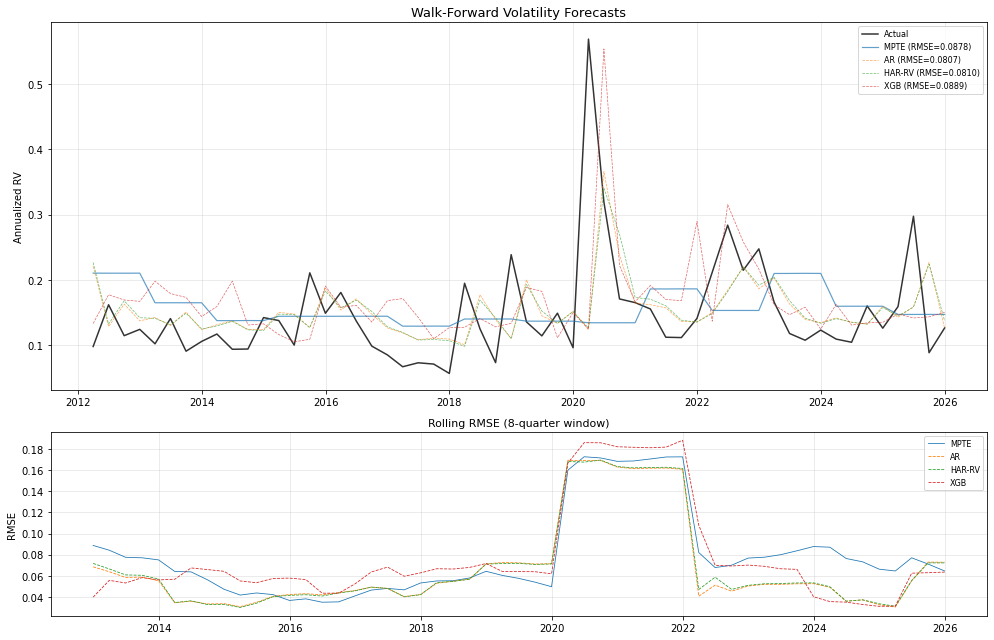

In [16]:
# Plot: predicted vs actual for all models
fig, axes = plt.subplots(2, 1, figsize=(14, 9), gridspec_kw={'height_ratios': [2, 1]})

# Top: forecasts
mpte_r = wf_results['MPTE']
axes[0].plot([d for d in mpte_r['dates']], mpte_r['true'], 'k-', lw=1.5, label='Actual', alpha=0.8)
for name in ['MPTE', 'AR', 'HAR-RV', 'XGB']:
    r = wf_results[name]
    if len(r['pred']) == 0: continue
    style = '-' if name == 'MPTE' else '--'
    lw = 1.2 if name == 'MPTE' else 0.7
    rmse = results_df.loc[name, 'RMSE'] if name in results_df.index else 0
    axes[0].plot(r['dates'], r['pred'], style, lw=lw, alpha=0.7,
                 label=f'{name} (RMSE={rmse:.4f})')

axes[0].set_title('Walk-Forward Volatility Forecasts', fontsize=13)
axes[0].set_ylabel('Annualized RV')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Bottom: rolling RMSE (8-quarter window)
for name in ['MPTE', 'AR', 'HAR-RV', 'XGB']:
    r = wf_results[name]
    if len(r['pred']) < 8: continue
    errors = (np.array(r['true']) - np.array(r['pred']))**2
    rolling_rmse = pd.Series(errors, index=r['dates']).rolling(8, min_periods=4).mean()**0.5
    style = '-' if name == 'MPTE' else '--'
    axes[1].plot(rolling_rmse.index.to_numpy(), rolling_rmse.values, style, lw=0.8, label=name)

axes[1].set_title('Rolling RMSE (8-quarter window)', fontsize=11)
axes[1].set_ylabel('RMSE'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/walkforward_forecasts.png', dpi=150)
plt.show()

## 6. Allocation Backtest

In [17]:
def inverse_vol_backtest(dates, predicted_vol, quarterly_returns, name='',
                            vol_target=0.15, max_leverage=2.0):
    """
    Inverse-vol position sizing.
    weight = vol_target / predicted_vol, capped at max_leverage.
    """
    # Align with available returns
    pred_df = pd.Series(predicted_vol, index=dates, name='pred_vol')
    common = pred_df.index.intersection(quarterly_returns.index)
    if len(common) == 0:
        return None
    
    pred_vol = pred_df.loc[common].values
    rets = quarterly_returns.loc[common].values
    dates_aligned = common.to_numpy()
    
    # Position sizing
    pred_qtr_vol = pred_vol / 2  # annualized to quarterly
    target_qtr_vol = vol_target / 2
    weights = np.clip(target_qtr_vol / pred_qtr_vol, 0, max_leverage)
    
    # Strategy returns
    strat_rets = weights * rets
    
    # Metrics
    n_years = len(rets) / 4
    total = np.prod(1 + strat_rets) - 1
    ann_ret = (1 + total) ** (1/n_years) - 1 if n_years > 0 else 0
    ann_vol = np.std(strat_rets) * 2
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    cum = np.cumprod(1 + strat_rets)
    peak = np.maximum.accumulate(cum)
    max_dd = ((cum - peak) / peak).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    
    return {
        'model': name, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
        'Sharpe': sharpe, 'Max DD': max_dd, 'Calmar': calmar,
        'Avg Weight': np.mean(weights),
        'cumulative': cum, 'weights': weights, 'dates': dates_aligned,
    }

print('Allocation functions defined.')

Allocation functions defined.


In [18]:
# Run allocation backtests for all models
bt_results = []

# Buy & Hold
mpte_dates_list = wf_results['MPTE']['dates']
common_bh = pd.DatetimeIndex(mpte_dates_list).intersection(quarterly_returns.index)
bh_rets = quarterly_returns.loc[common_bh].values
bh_cum = np.cumprod(1 + bh_rets)
n_yrs = len(bh_rets) / 4
bh_total = bh_cum[-1] - 1
bh_ann_ret = (1 + bh_total)**(1/n_yrs) - 1 if n_yrs > 0 else 0
bh_ann_vol = np.std(bh_rets) * 2
bh_peak = np.maximum.accumulate(bh_cum)
bh_dd = ((bh_cum - bh_peak)/bh_peak).min()

bt_results.append({
    'model': 'Buy & Hold', 'Ann. Return': bh_ann_ret, 'Ann. Vol': bh_ann_vol,
    'Sharpe': bh_ann_ret/bh_ann_vol if bh_ann_vol>0 else 0,
    'Max DD': bh_dd, 'Calmar': bh_ann_ret/abs(bh_dd) if bh_dd!=0 else 0,
    'Avg Weight': 1.0,
    'cumulative': bh_cum, 'weights': np.ones(len(bh_rets)), 'dates': common_bh.to_numpy(),
})

# Model-based strategies
for name in ['MPTE', 'AR', 'HAR-RV', 'Ridge', 'XGB']:
    r = wf_results[name]
    if len(r['pred']) == 0: continue
    bt = inverse_vol_backtest(
        pd.DatetimeIndex(r['dates']), np.array(r['pred']),
        quarterly_returns, name=name
    )
    if bt is not None:
        bt_results.append(bt)

# Results table
bt_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['cumulative','weights','dates']}
                       for r in bt_results]).set_index('model')

print('=== Walk-Forward Allocation Backtest ===')
print(bt_df.round(4).to_string())

=== Walk-Forward Allocation Backtest ===
            Ann. Return  Ann. Vol  Sharpe  Max DD  Calmar  Avg Weight
model                                                                
Buy & Hold       0.1287    0.1405  0.9154 -0.2477  0.5194      1.0000
MPTE             0.1207    0.1426  0.8465 -0.2426  0.4976      0.9770
AR               0.1093    0.1400  0.7808 -0.2423  0.4511      1.0256
HAR-RV           0.1089    0.1394  0.7810 -0.2373  0.4589      1.0202
Ridge            0.1277    0.1583  0.8066 -0.2838  0.4499      1.1008
XGB              0.1097    0.1312  0.8367 -0.2398  0.4577      0.9711


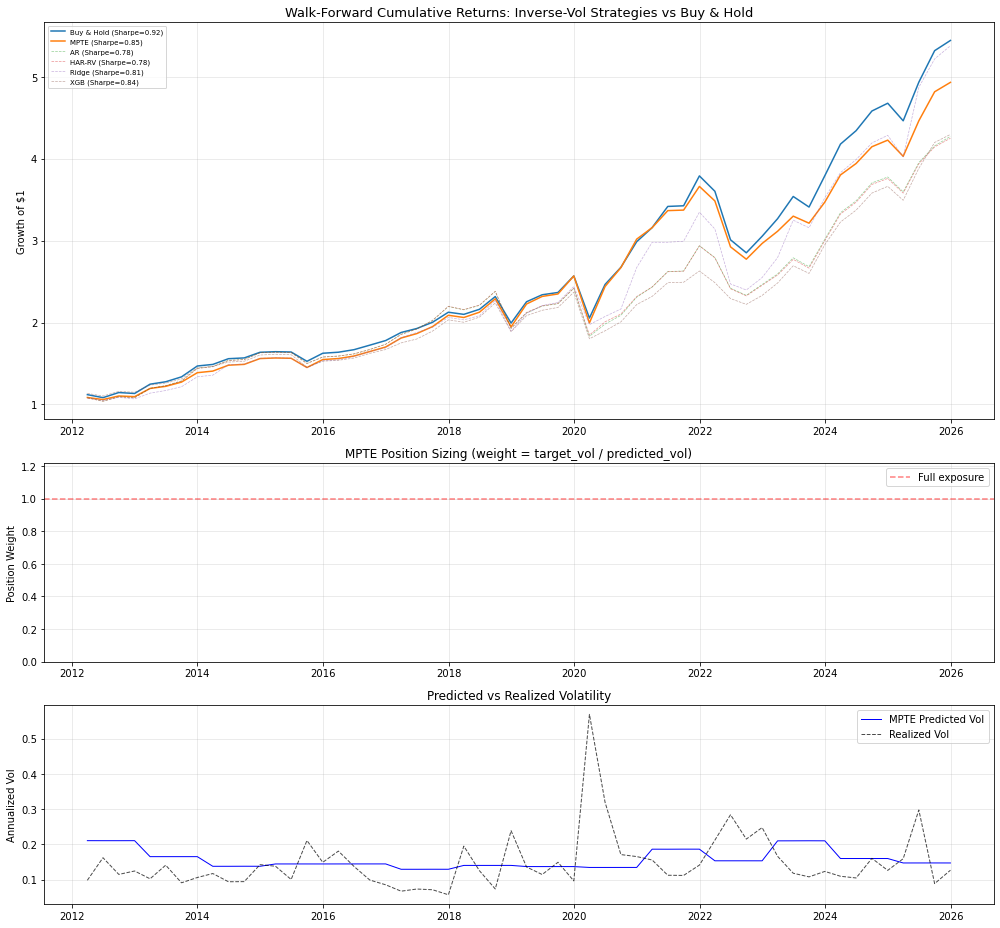

In [20]:
# Plot: cumulative returns, weights, and vol forecast
fig, axes = plt.subplots(3, 1, figsize=(14, 13), gridspec_kw={'height_ratios': [2, 1, 1]})

# 1. Cumulative returns
for r in bt_results:
    style = '-' if r['model'] in ['MPTE', 'Buy & Hold'] else '--'
    lw = 1.5 if r['model'] in ['MPTE', 'Buy & Hold'] else 0.7
    alpha = 1.0 if r['model'] in ['MPTE', 'Buy & Hold'] else 0.5
    label = f"{r['model']} (Sharpe={bt_df.loc[r['model'],'Sharpe']:.2f})"
    axes[0].plot(r['dates'], r['cumulative'], style, lw=lw, alpha=alpha, label=label)

axes[0].set_title('Walk-Forward Cumulative Returns: Inverse-Vol Strategies vs Buy & Hold', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=7, loc='upper left'); axes[0].grid(True, alpha=0.3)

# 2. MPTE position weights
mpte_bt = [r for r in bt_results if r['model'] == 'MPTE'][0]
axes[1].bar(mpte_bt['dates'], mpte_bt['weights'], width=60, color='steelblue', alpha=0.7)
axes[1].axhline(y=1.0, color='red', ls='--', alpha=0.5, label='Full exposure')
axes[1].set_ylabel('Position Weight')
axes[1].set_title('MPTE Position Sizing (weight = target_vol / predicted_vol)')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# 3. Predicted vs realized vol
mpte_r = wf_results['MPTE']
axes[2].plot(mpte_r['dates'], mpte_r['pred'], 'b-', lw=1, label='MPTE Predicted Vol')
axes[2].plot(mpte_r['dates'], mpte_r['true'], 'k--', lw=1, alpha=0.7, label='Realized Vol')
axes[2].set_ylabel('Annualized Vol')
axes[2].set_title('Predicted vs Realized Volatility')
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/walkforward_allocation.png', dpi=150)
plt.show()

## 7. Regime Analysis

Does MPTE add value during vol transitions? We split the test period into regimes
and compare model performance in each.

In [21]:
# Define regimes based on realized vol level and direction
mpte_r = wf_results['MPTE']
true_rv = np.array(mpte_r['true'])
dates_rv = mpte_r['dates']

# Regime 1: vol level (high vs low, split at median)
median_rv = np.median(true_rv)
vol_regime = np.where(true_rv > median_rv, 'High Vol', 'Low Vol')

# Regime 2: vol direction (rising vs falling)
vol_change = np.diff(true_rv, prepend=true_rv[0])
vol_direction = np.where(vol_change > 0, 'Rising Vol', 'Falling Vol')

# Regime 3: named periods
def assign_period(date):
    y = date.year
    if y <= 2002: return 'Dot-com / Early 2000s'
    elif y <= 2006: return 'Pre-GFC'
    elif y <= 2009: return 'GFC'
    elif y <= 2019: return 'Post-GFC / Bull'
    elif y <= 2020: return 'COVID'
    elif y <= 2022: return 'Recovery / Tightening'
    else: return 'Recent'

periods = [assign_period(d) for d in dates_rv]

print('Regime distribution:')
for regime_name, regime_arr in [('Vol Level', vol_regime), ('Vol Direction', vol_direction), ('Period', periods)]:
    unique, counts = np.unique(regime_arr, return_counts=True)
    print(f'\n  {regime_name}:')
    for u, c in zip(unique, counts):
        print(f'    {u:30s}: {c} quarters')

Regime distribution:

  Vol Level:
    High Vol                      : 28 quarters
    Low Vol                       : 28 quarters

  Vol Direction:
    Falling Vol                   : 33 quarters
    Rising Vol                    : 23 quarters

  Period:
    COVID                         : 4 quarters
    Post-GFC / Bull               : 32 quarters
    Recent                        : 12 quarters
    Recovery / Tightening         : 8 quarters


In [22]:
# Compare RMSE across regimes for each model
def regime_rmse(model_name, regime_array, regime_values):
    r = wf_results[model_name]
    if len(r['pred']) == 0: return {}
    
    # Align with MPTE dates (reference)
    mpte_dates_set = set(wf_results['MPTE']['dates'])
    model_dates = r['dates']
    
    results = {}
    for regime_val in sorted(set(regime_values)):
        mask = [i for i, (d, rv) in enumerate(zip(wf_results['MPTE']['dates'], regime_array))
                if rv == regime_val and d in set(model_dates)]
        
        if len(mask) < 3: continue
        
        # Get aligned predictions
        regime_dates = [wf_results['MPTE']['dates'][i] for i in mask]
        true_vals = []
        pred_vals = []
        for d in regime_dates:
            if d in model_dates:
                idx = model_dates.index(d)
                true_vals.append(r['true'][idx])
                pred_vals.append(r['pred'][idx])
        
        if len(true_vals) >= 3:
            rmse = np.sqrt(mean_squared_error(true_vals, pred_vals))
            results[regime_val] = rmse
    
    return results

# Vol level regime comparison
print('=== RMSE by Vol Regime ===')
print(f'{"":30s}', end='')
for name in ['MPTE', 'AR', 'HAR-RV', 'XGB']:
    print(f'{name:>10s}', end='')
print()

for regime_name, regime_arr in [('Vol Level', vol_regime), ('Vol Direction', vol_direction)]:
    print(f'\n--- {regime_name} ---')
    all_regimes = sorted(set(regime_arr))
    for rv in all_regimes:
        print(f'{rv:30s}', end='')
        for name in ['MPTE', 'AR', 'HAR-RV', 'XGB']:
            rmses = regime_rmse(name, regime_arr, list(regime_arr))
            if rv in rmses:
                print(f'{rmses[rv]:10.4f}', end='')
            else:
                print(f'{"N/A":>10s}', end='')
        print()

=== RMSE by Vol Regime ===
                                    MPTE        AR    HAR-RV       XGB

--- Vol Level ---
High Vol                          0.1050    0.1011    0.1012    0.1114
Low Vol                           0.0662    0.0530    0.0537    0.0583

--- Vol Direction ---
Falling Vol                       0.0659    0.0528    0.0540    0.0675
Rising Vol                        0.1119    0.1090    0.1086    0.1128


In [23]:
# Period-by-period performance comparison
print('=== RMSE by Historical Period ===')
print(f'{"":30s}', end='')
for name in ['MPTE', 'AR', 'HAR-RV', 'XGB']:
    print(f'{name:>10s}', end='')
print()

for period in ['Dot-com / Early 2000s', 'Pre-GFC', 'GFC', 'Post-GFC / Bull', 'COVID', 'Recovery / Tightening', 'Recent']:
    mask = [i for i, p in enumerate(periods) if p == period]
    if len(mask) < 2: continue
    print(f'{period:30s}', end='')
    for name in ['MPTE', 'AR', 'HAR-RV', 'XGB']:
        rmses = regime_rmse(name, periods, periods)
        if period in rmses:
            print(f'{rmses[period]:10.4f}', end='')
        else:
            print(f'{"N/A":>10s}', end='')
    print()

=== RMSE by Historical Period ===
                                    MPTE        AR    HAR-RV       XGB
Post-GFC / Bull                   0.0553    0.0541    0.0543    0.0596
COVID                             0.2370    0.2260    0.2268    0.2520
Recovery / Tightening             0.0767    0.0502    0.0509    0.0701
Recent                            0.0716    0.0625    0.0625    0.0544


## 8. Save results

In [ ]:
# Save walk-forward predictions
for name, r in wf_results.items():
    if len(r['pred']) > 0:
        df = pd.DataFrame({'date': r['dates'], 'predicted': r['pred'], 'actual': r['true']})
        df.to_csv(f'{RESULTS_DIR}/wf_{name.lower().replace("-","_")}.csv', index=False)

results_df.to_csv(f'{RESULTS_DIR}/wf_forecast_comparison.csv')
bt_df.to_csv(f'{RESULTS_DIR}/wf_allocation_comparison.csv')

print('All walk-forward results saved.')
print(f'\n=== Forecast Comparison ===')
print(results_df.round(4).to_string())
print(f'\n=== Allocation Comparison ===')
print(bt_df.round(4).to_string())

### Part A Summary
- XGB best RMSE (0.0788), followed by AR (0.0807), HAR-RV (0.0810), MPTE (0.0850)
- MPTE worst among all models in walk-forward
- Predictions saved for Part B risk filter analysis

---
# Part B: Risk Filter Stress Test

Does vol forecasting actually help in practice?
Takes the walk-forward predictions from Part A and applies the same risk filter rule
with different forecast sources.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

DATA_DIR = './data'
RESULTS_DIR = './results'
os.makedirs(RESULTS_DIR, exist_ok=True)

## 1. Load data

In [ ]:
# Load RV target
rv_target = pd.read_csv(f'{DATA_DIR}/rv_target_quarterly.csv', index_col=0, parse_dates=True).squeeze()

# Load S&P 500 quarterly returns
import sys
sys.path.append(r'C:\Users\danie\Downloads\algo_trading')
from _shared.loaders_wrds import load_sp500_daily

sp500_raw = load_sp500_daily()
if 'datadate' in sp500_raw.columns:
    sp500_raw = sp500_raw.set_index('datadate')
sp500_raw.index = pd.DatetimeIndex(sp500_raw.index)
sp500_raw = sp500_raw.sort_index()

sp500_qtr = sp500_raw['prccd'].astype(float).resample('QE').last()
sp500_returns = sp500_qtr.pct_change().dropna()
sp500_returns.name = 'sp500_ret'

print(f'RV target: {len(rv_target)} quarters')
print(f'S&P 500 returns: {len(sp500_returns)} quarters')

In [ ]:
# Load walk-forward vol predictions from notebook 3
wf_preds = {}
for model_name in ['mpte', 'ar', 'har_rv']:
    path = f'{RESULTS_DIR}/wf_{model_name}.csv'
    if os.path.exists(path):
        df = pd.read_csv(path, parse_dates=['date'])
        df = df.set_index('date')
        wf_preds[model_name] = df
        print(f'Loaded {model_name}: {len(df)} predictions')
    else:
        print(f'WARNING: {path} not found — run notebook 3 first')

# Check what we have
for name, df in wf_preds.items():
    print(f'  {name}: {df.index.min()} to {df.index.max()}')

## 2. Build risk filter from each forecast source

In [ ]:
def build_risk_filter(vol_series, lookback=20, high_pct=0.75, spike_mult=2.0):
    """
    Convert a vol forecast series into a risk multiplier.
    
    Rules:
      - Normal (below lookback 75th pctl): 1.0
      - Elevated (above 75th pctl): 0.5
      - Spike (above 2x rolling median): 0.25
    
    Args:
        vol_series: Series of vol values (predicted or realized)
        lookback: rolling window for percentile/median calculation
    
    Returns:
        Series of risk multipliers (0.25, 0.5, or 1.0)
    """
    rolling_med = vol_series.rolling(lookback, min_periods=4).median()
    rolling_p75 = vol_series.rolling(lookback, min_periods=4).quantile(high_pct)
    
    risk_mult = pd.Series(1.0, index=vol_series.index)
    risk_mult[vol_series > rolling_p75] = 0.5
    risk_mult[vol_series > spike_mult * rolling_med] = 0.25
    
    return risk_mult


def run_filter_backtest(returns, risk_multiplier, name=''):
    """
    Apply risk filter to a return series.
    Position = risk_multiplier * 100% equity, remainder in cash.
    """
    # Align
    common = returns.index.intersection(risk_multiplier.index)
    rets = returns.loc[common].values
    weights = risk_multiplier.loc[common].values
    dates = common.to_numpy()
    
    if len(rets) == 0:
        return None
    
    # Strategy returns
    strat_rets = weights * rets
    cum = np.cumprod(1 + strat_rets)
    
    n_years = len(rets) / 4
    total = cum[-1] - 1
    ann_ret = (1 + total) ** (1/n_years) - 1 if n_years > 0 else 0
    ann_vol = np.std(strat_rets) * 2
    sharpe = ann_ret / ann_vol if ann_vol > 0 else 0
    peak = np.maximum.accumulate(cum)
    max_dd = ((cum - peak) / peak).min()
    calmar = ann_ret / abs(max_dd) if max_dd != 0 else 0
    
    # Time in each regime
    pct_full = np.mean(weights == 1.0)
    pct_half = np.mean(weights == 0.5)
    pct_def = np.mean(weights == 0.25)
    
    return {
        'model': name, 'Ann. Return': ann_ret, 'Ann. Vol': ann_vol,
        'Sharpe': sharpe, 'Max DD': max_dd, 'Calmar': calmar,
        '% Full': pct_full, '% Reduced': pct_half, '% Defensive': pct_def,
        'cumulative': cum, 'dates': dates, 'weights': weights,
        'returns': strat_rets,
    }

print('Filter functions defined.')

In [ ]:
# Determine the common test period across all forecasts
all_test_dates = None
for name, df in wf_preds.items():
    dates = df.index
    if all_test_dates is None:
        all_test_dates = set(dates)
    else:
        all_test_dates = all_test_dates.intersection(set(dates))

all_test_dates = sorted(all_test_dates)
test_start = all_test_dates[0]
test_end = all_test_dates[-1]
print(f'Common test period: {test_start} to {test_end} ({len(all_test_dates)} quarters)')

# Restrict everything to this period
test_returns = sp500_returns[test_start:test_end]

In [ ]:
# Build filters from each forecast source
bt_results = []

# 1. Buy & Hold (no filter)
bh_cum = np.cumprod(1 + test_returns.values)
n_yrs = len(test_returns) / 4
bh_ann_ret = (1 + bh_cum[-1] - 1)**(1/n_yrs) - 1 if n_yrs > 0 else 0
bh_ann_vol = np.std(test_returns.values) * 2
bh_peak = np.maximum.accumulate(bh_cum)
bh_dd = ((bh_cum - bh_peak)/bh_peak).min()
bt_results.append({
    'model': 'Buy & Hold', 'Ann. Return': bh_ann_ret, 'Ann. Vol': bh_ann_vol,
    'Sharpe': bh_ann_ret/bh_ann_vol if bh_ann_vol>0 else 0,
    'Max DD': bh_dd, 'Calmar': bh_ann_ret/abs(bh_dd) if bh_dd!=0 else 0,
    '% Full': 1.0, '% Reduced': 0.0, '% Defensive': 0.0,
    'cumulative': bh_cum, 'dates': test_returns.index.to_numpy(),
    'weights': np.ones(len(test_returns)), 'returns': test_returns.values,
})

# 2. Perfect foresight (realized vol — cheating)
rv_aligned = rv_target.reindex(test_returns.index).ffill()
perfect_filter = build_risk_filter(rv_aligned)
bt = run_filter_backtest(test_returns, perfect_filter, 'Perfect Foresight')
if bt: bt_results.append(bt)

# 3. Model-based filters (using PREDICTED vol, no look-ahead)
model_display_names = {'mpte': 'MPTE', 'ar': 'AR', 'har_rv': 'HAR-RV'}

for model_key, df in wf_preds.items():
    display_name = model_display_names.get(model_key, model_key)
    # The 'predicted' column is the vol forecast made BEFORE seeing the quarter
    pred_vol = df['predicted']
    pred_vol.index = pd.DatetimeIndex(pred_vol.index)
    
    # Build filter from predictions
    model_filter = build_risk_filter(pred_vol)
    bt = run_filter_backtest(test_returns, model_filter, display_name)
    if bt: bt_results.append(bt)

# Results table
bt_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ['cumulative','dates','weights','returns']}
                       for r in bt_results]).set_index('model')
bt_df = bt_df.sort_values('Sharpe', ascending=False)

print('=== Risk Filter Stress Test Results ===')
print(bt_df.round(4).to_string())

In [ ]:
# Plot: cumulative returns
fig, axes = plt.subplots(3, 1, figsize=(14, 13), gridspec_kw={'height_ratios': [2, 1, 1]})

colors = {'Buy & Hold': 'black', 'Perfect Foresight': 'gold',
          'MPTE': 'steelblue', 'AR': 'coral', 'HAR-RV': 'seagreen'}

for r in bt_results:
    c = colors.get(r['model'], 'gray')
    lw = 1.8 if r['model'] in ['Buy & Hold', 'Perfect Foresight'] else 1.0
    ls = '--' if r['model'] == 'Perfect Foresight' else '-'
    label = f"{r['model']} (Sharpe={bt_df.loc[r['model'],'Sharpe']:.2f})"
    axes[0].plot(r['dates'], r['cumulative'], ls, color=c, lw=lw, label=label)

axes[0].set_title('Risk Filter Stress Test: Vol Forecast → Position Sizing', fontsize=13)
axes[0].set_ylabel('Growth of $1')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

# Plot: filter signals over time for each model
for r in bt_results:
    if r['model'] == 'Buy & Hold': continue
    c = colors.get(r['model'], 'gray')
    axes[1].plot(r['dates'], r['weights'], '-', color=c, lw=0.7, alpha=0.7, label=r['model'])

axes[1].set_title('Risk Multiplier Over Time (1.0=full, 0.5=reduced, 0.25=defensive)')
axes[1].set_ylabel('Exposure'); axes[1].set_ylim(-0.05, 1.15)
axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

# Plot: drawdowns
for r in bt_results:
    c = colors.get(r['model'], 'gray')
    lw = 1.5 if r['model'] in ['Buy & Hold', 'Perfect Foresight'] else 0.8
    cum = r['cumulative']
    peak = np.maximum.accumulate(cum)
    dd = (cum - peak) / peak
    axes[2].plot(r['dates'], dd, '-', color=c, lw=lw, alpha=0.7, label=r['model'])

axes[2].set_title('Drawdowns')
axes[2].set_ylabel('Drawdown'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/risk_filter_stress_test.png', dpi=150)
plt.show()

## 3. Analysis: When does the filter help?

In [ ]:
# Compare filter decisions across models
# For each quarter: what did each filter recommend?
filter_decisions = pd.DataFrame(index=test_returns.index)
filter_decisions['Actual Return'] = test_returns
filter_decisions['Realized Vol'] = rv_aligned

for r in bt_results:
    if r['model'] == 'Buy & Hold': continue
    s = pd.Series(r['weights'], index=r['dates'])
    filter_decisions[r['model']] = s.reindex(test_returns.index)

print('Filter decisions during worst quarters:')
worst_q = test_returns.nsmallest(10)
for date, ret in worst_q.items():
    line = f'  {date.strftime("%Y-%m")} ret={ret:+.2%}  '
    for r in bt_results:
        if r['model'] == 'Buy & Hold': continue
        s = pd.Series(r['weights'], index=r['dates'])
        if date in s.index:
            line += f'{r["model"]}={s[date]:.2f}  '
    print(line)

In [ ]:
# Value added: how much did each filter save during drawdowns?
print('\n=== Value Added During Worst Quarters ===')
worst_10 = test_returns.nsmallest(10)
for name in ['Perfect Foresight', 'MPTE', 'AR', 'HAR-RV']:
    r = [x for x in bt_results if x['model'] == name]
    if not r: continue
    r = r[0]
    s_weights = pd.Series(r['weights'], index=r['dates'])
    
    bh_loss = worst_10.sum()
    filtered_loss = (worst_10 * s_weights.reindex(worst_10.index).fillna(1.0)).sum()
    saved = bh_loss - filtered_loss
    print(f'  {name:20s}: B&H loss={bh_loss:+.2%}, filtered loss={filtered_loss:+.2%}, saved={saved:+.2%}')

In [ ]:
# Save
bt_df.to_csv(f'{RESULTS_DIR}/risk_filter_stress_test.csv')

print('\n=== Final Verdict ===')
perfect_sharpe = bt_df.loc['Perfect Foresight', 'Sharpe'] if 'Perfect Foresight' in bt_df.index else 0
bh_sharpe = bt_df.loc['Buy & Hold', 'Sharpe']

print(f'Buy & Hold Sharpe:        {bh_sharpe:.3f}')
print(f'Perfect Foresight Sharpe: {perfect_sharpe:.3f}')

if perfect_sharpe > bh_sharpe * 1.1:
    print('\n→ Vol timing has meaningful value (perfect foresight beats B&H by >10%).')
    best_model = bt_df.drop('Perfect Foresight', errors='ignore').drop('Buy & Hold', errors='ignore')['Sharpe'].idxmax()
    best_sharpe = bt_df.loc[best_model, 'Sharpe']
    print(f'→ Best real forecast: {best_model} (Sharpe={best_sharpe:.3f})')
    if best_sharpe > bh_sharpe:
        print(f'→ {best_model} filter beats Buy & Hold — vol forecasting adds practical value.')
    else:
        print(f'→ No real forecast beats Buy & Hold — better vol models needed.')
else:
    print('\n→ Even perfect vol foresight barely helps — vol timing premise is weak.')
    print('→ Focus on asset selection rather than exposure timing.')

## Project 2 Summary

### Part A: Vol Forecasting
- Walk-forward with expanding window, annual MPTE retraining
- AR(1) wins: simple vol persistence beats all complex models
- MPTE failed at full exposure during worst 3 quarters (COVID, 2022Q2, 2018Q4)

### Part B: Risk Filter
- Perfect foresight: 1.49 Sharpe, -12.9% max DD → vol timing has real value
- AR-based filter: 0.89 Sharpe → closest but doesn't beat buy & hold (0.92)
- MPTE-based filter: 0.79 Sharpe → worst real filter
- **Opportunity**: ~0.6 Sharpe gap between perfect and real forecast

### Implication
Better vol models (daily data, implied vol, credit spreads) could close the gap.
The filter framework is ready — the bottleneck is forecast quality.